# 4.1

In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from configs.base.env_cfg import device, torch_dtype

# ============================================================
# Config & BS model imports
# ============================================================
from src.bs_model import sim_bs_paths_cfg
from src.rl_models import q_diff_risk_lambda, q_diff_critic_risk_lambda
from utils.pricing.pvv_bs_model import PVVBSModel

from utils.analysis.delta_pnl_analysis import delta_hedge_full_analytics

# ============================================================
# QLBS models
# ============================================================
from utils.model_saver import load_full_experiment
from src.data_processing import make_state_t



In [32]:
# ============================================================
# Load BS-trained ACC-model
# ============================================================

load_dir = "models/4_1_bs_0_15"   # <<< 改成你的 BS 训练目录
actor_lambda=100_000.0
all_critic_risk_lambda = [0, 0.001, 0.005, 0.01]

(
    critic0,
    market_cfg,
    critic0_cfg,
    runtime_cfg,
    actor,
    actor_cfg,
    critic,
    critic_cfg
) = load_full_experiment(
    load_dir=load_dir,
    device=device,
    torch_dtype=torch_dtype,
    actor_lambda=actor_lambda,
    critic_lambda=actor_lambda,
)



=== Loading full experiment ===
当前工作目录：/Users/hy/PycharmProjects/qlbs_rl
当前已是qlbs_rl根目录，无需切换
[MarketArtifactLoader] Loaded market artifact: 
path            : models/4_1_bs_0_15
  - MarketCFG   : market_cfg.json
  - Critic0     : critic0.pt
  - RuntimeCFG  : runtime_cfg.json

Market artifact loaded
[ActorLoader] Loaded actor λ=100000.0
  path: models/4_1_bs_0_15/actor_lambda_100000.0000/actor.pt
  device: mps, dtype: torch.float32
Actor loaded (λ=100000.0)
[CriticLoader] Loaded critic λ=100000.0
  path: models/4_1_bs_0_15/actor_lambda_100000.0000/critic_100000.0000.pt
  device: mps
Critic loaded (λ=100000.0)
=== Full experiment loaded ===


In [33]:
# ============================================================
# Market config (BS)
# ============================================================

S0 = market_cfg.S0
mu = market_cfg.mu          # risk-neutral: mu = r
r = market_cfg.r
sigma = market_cfg.sigma

T = market_cfg.T
T_steps = market_cfg.T_steps
dt = market_cfg.dt

K = S0
option_type = market_cfg.option_type
transaction_cost_rate = market_cfg.transaction_cost_rate


In [34]:
# ============================================================
# Simulate BS paths
# ============================================================
N_paths = 50_000

S_paths_t, log_returns, _ = sim_bs_paths_cfg(
    s_cfg=market_cfg,
    N_paths=N_paths,
    T_steps=T_steps,
)

# torch -> numpy
S_paths = S_paths_t.cpu().numpy()           # (N, T+1)


In [35]:
# ============================================================
# tau vector
# ============================================================
tau_vec = T - np.arange(T_steps + 1) * float(dt)
tau_vec = np.maximum(tau_vec, 1e-6)


In [36]:
# ============================================================
# BS benchmark price & delta (PVV)
# ============================================================
bs_pricer = PVVBSModel(market_cfg)

S_mat = S_paths[:, :-1]                     # (N, T)
K_mat = np.full_like(S_mat, K)

price_mat, delta_mat_bs = bs_pricer.price_and_delta(
    S_mat=S_mat,
    K_mat=K_mat,
    tau_vec=tau_vec[:-1],
)

# assemble delta paths (including maturity)
delta_paths_bs = np.zeros_like(S_paths)
delta_paths_bs[:, :-1] = delta_mat_bs

if option_type == "call":
    delta_T = (S_paths[:, -1] > K).astype(float)
else:
    delta_T = -(S_paths[:, -1] < K).astype(float)

delta_paths_bs[:, -1] = delta_T


In [37]:
# ============================================================
# Initial option price (BS)
# ============================================================
initial_option_price = price_mat[:, 0].mean()

# ============================================================
# BS benchmark PnL
# ============================================================
results_bs = delta_hedge_full_analytics(
    S_paths=S_paths,
    delta_paths=delta_paths_bs,
    initial_option_price=initial_option_price,
    K=K,
    option_type=option_type,
    r=r,
    transaction_cost_rate=transaction_cost_rate,
    dt=dt,
)

terminal_pnl_bs = results_bs["terminal_pnl"]

@torch.no_grad()
def acc_slice(
        actor, critic0, critic,
        S_path: torch.Tensor,
        K,
        actor_risk_lambda: float,
        all_critic_risk_lambda: list,
        t_path: torch.Tensor,
        device, torch_dtype,
):
    S_over_K = S_path / K
    state = make_state_t(
        S_over_K,
        t_path,
    )
    actions = actor.mean(state)
    
    astar = critic.a_star(state)

    Q0 = critic0(state, actions)

    # 20000 倍
    all_critic_risk_lambda = np.array(all_critic_risk_lambda) * 20000

    QQ = q_diff_critic_risk_lambda(
        critic0 = critic0,
        critic = critic,
        actions = actions,
        actor_risk_lambda=actor_risk_lambda,
        all_critic_risk_lambda = all_critic_risk_lambda,
        state = state,
    )

    return actions * (K / S_path), astar * (K / S_path), -Q0 * K, - QQ * K


In [38]:
# ============================================================
# QLBS delta paths
# ============================================================
with torch.no_grad():
    T_mat = (
        torch.tensor(tau_vec[:-1], device=device, dtype=torch_dtype)
        .unsqueeze(0)
        .expand(N_paths, T_steps)
    )

    actions, a_star, Q_critic0, Q_critic = acc_slice(
        actor=actor,
        critic0=critic0,
        critic=critic,
        S_path=S_paths_t[:, :-1],
        K=K,
        actor_risk_lambda=actor_lambda,
        all_critic_risk_lambda=all_critic_risk_lambda,
        t_path=T_mat,
        device=device,
        torch_dtype=torch_dtype,
    )

acc_actions = np.zeros_like(S_paths)
acc_actions[:, :-1] = actions.cpu().numpy()
acc_actions[:, -1] = delta_paths_bs[:, -1]   # same terminal payoff

acc_astar = np.zeros_like(S_paths)
acc_astar[:, :-1] = a_star.cpu().numpy()
acc_astar[:, -1] = delta_paths_bs[:, -1]   # same terminal payoff


In [39]:
# ============================================================
# QLBS PnL
# ============================================================
acc_results_actions = delta_hedge_full_analytics(
    S_paths=S_paths,
    delta_paths=acc_actions,
    initial_option_price=initial_option_price,
    K=K,
    option_type=option_type,
    r=r,
    transaction_cost_rate=transaction_cost_rate,
    dt=dt,
)

acc_results_astar = delta_hedge_full_analytics(
    S_paths=S_paths,
    delta_paths=acc_astar,
    initial_option_price=initial_option_price,
    K=K,
    option_type=option_type,
    r=r,
    transaction_cost_rate=transaction_cost_rate,
    dt=dt,
)

acc_terminal_pnl_actions = acc_results_actions["terminal_pnl"]
acc_terminal_pnl_astar = acc_results_astar["terminal_pnl"]

In [40]:
# ============================================================
# Pathwise plots (BS)
# ============================================================
N = S_paths.shape[0]
n_plot = 10
rng = np.random.default_rng(42)
plot_indices = rng.choice(N, size=n_plot, replace=False)

t_grid = np.arange(S_paths.shape[1])

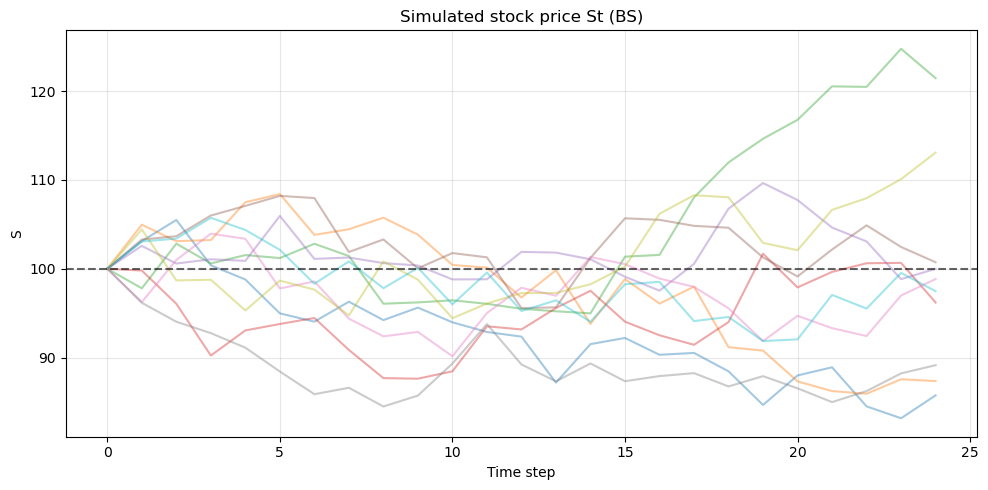

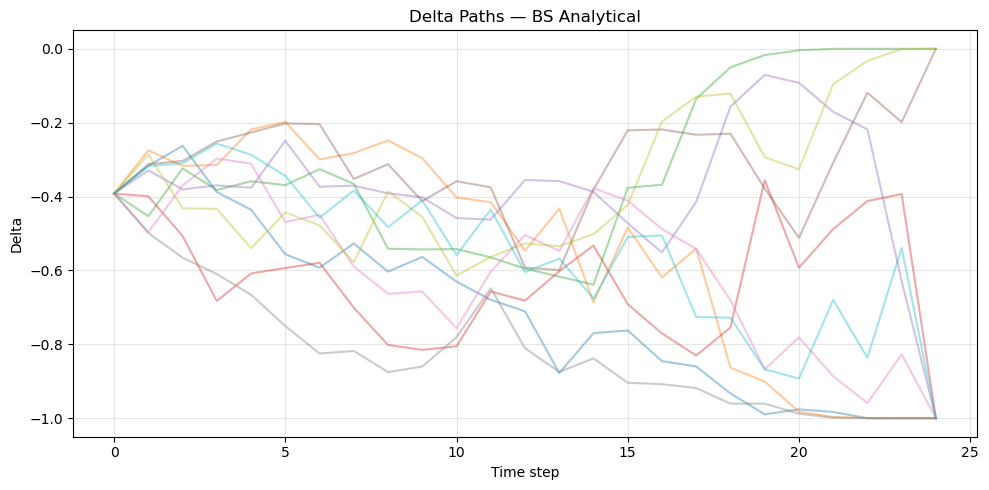

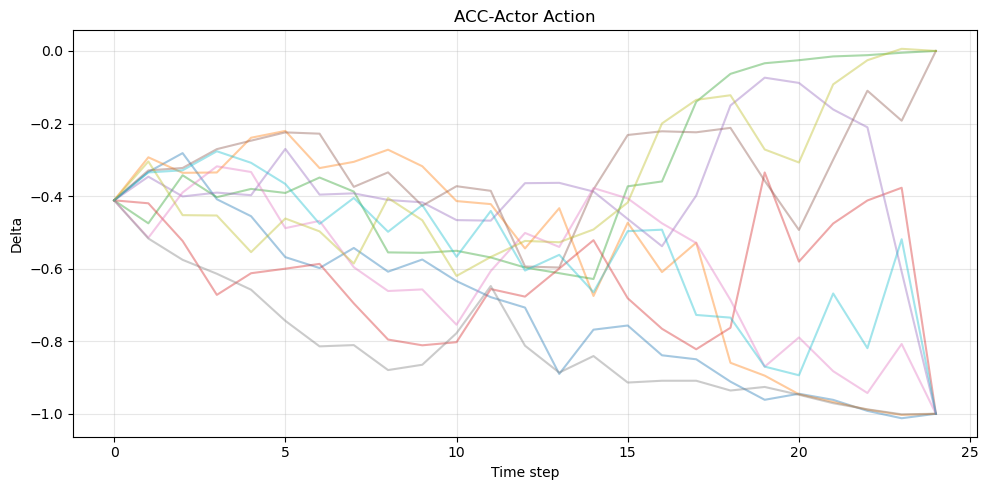

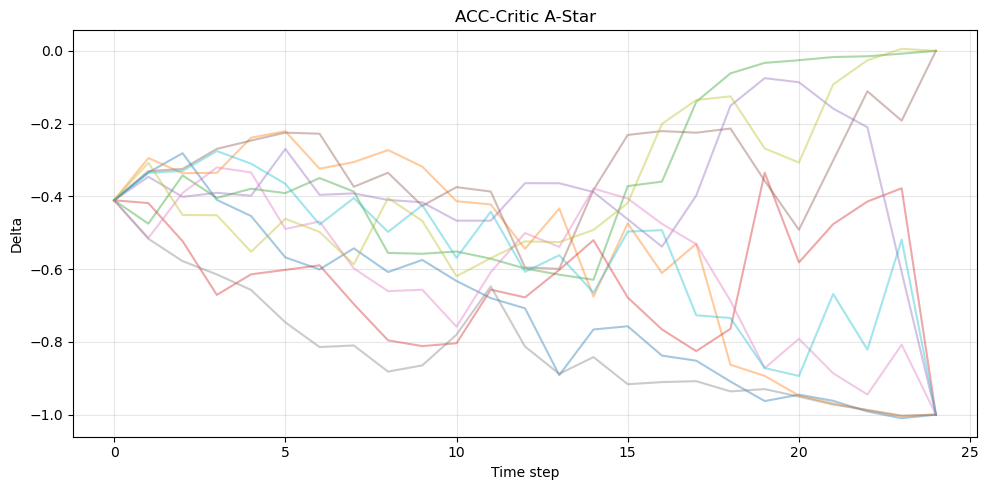

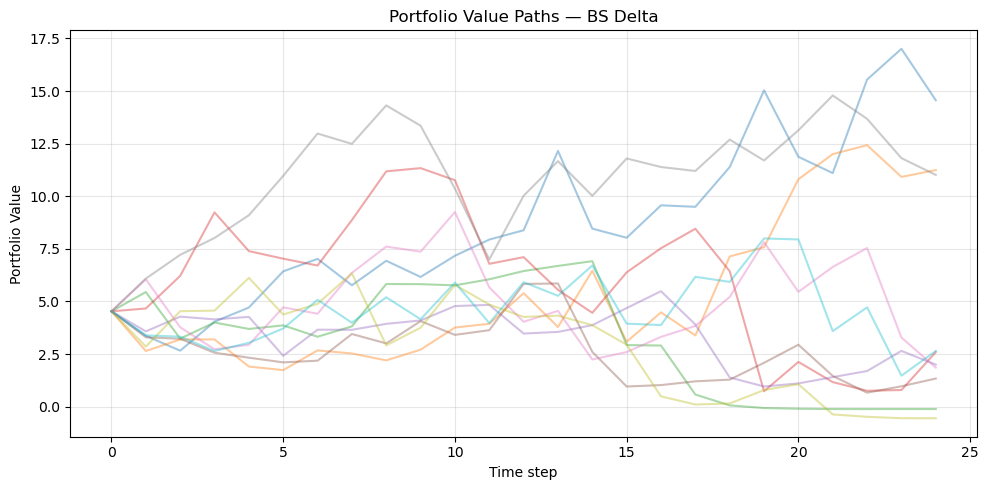

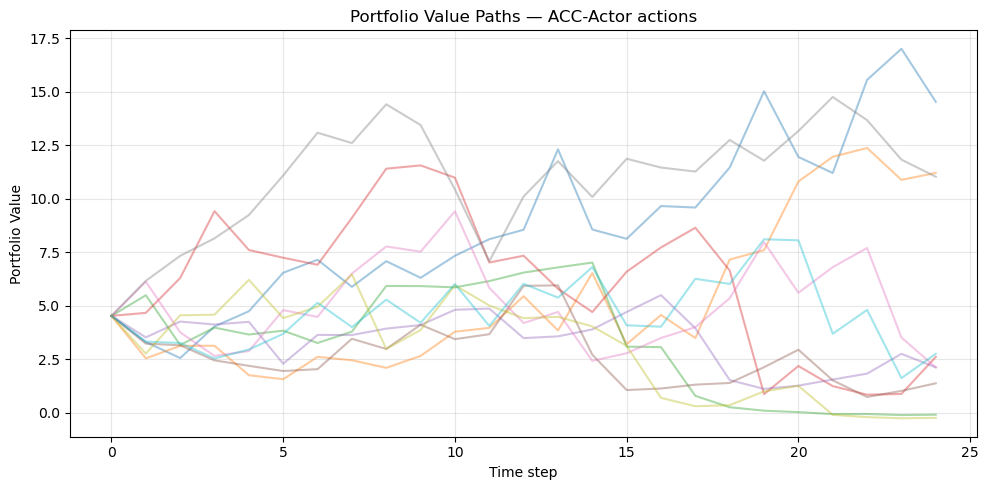

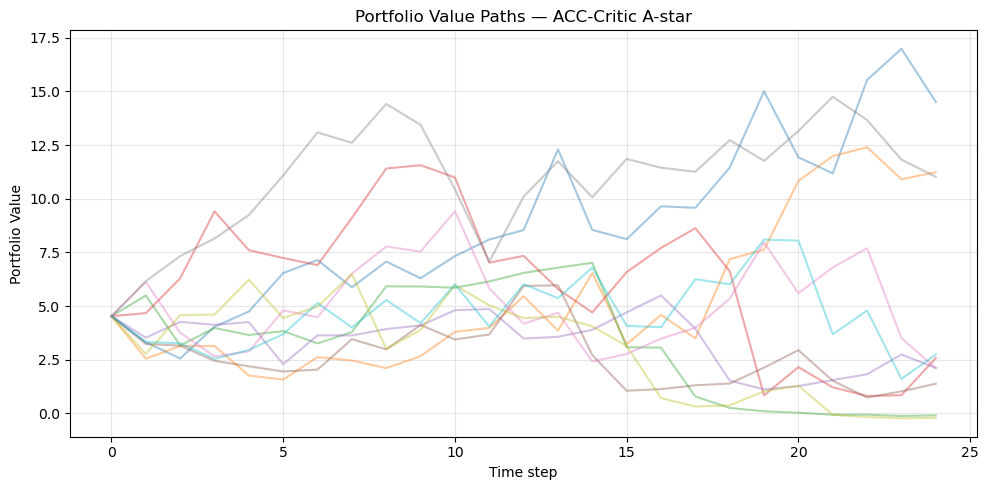

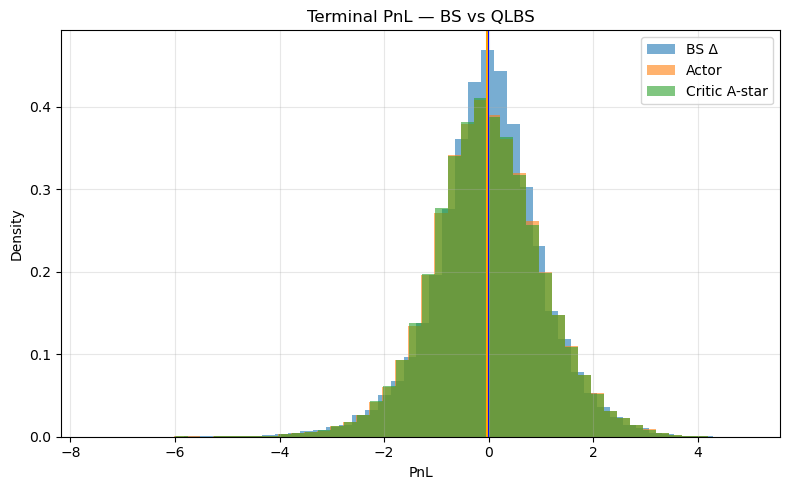

In [41]:
# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid, S_paths[i], alpha=0.4)
plt.axhline(K, color="black", ls="--", alpha=0.6)
plt.title("Simulated stock price St (BS)")
plt.xlabel("Time step")
plt.ylabel("S")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid, delta_paths_bs[i], alpha=0.4)
plt.title("Delta Paths — BS Analytical")
plt.xlabel("Time step")
plt.ylabel("Delta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid, acc_actions[i], alpha=0.4)
plt.title("ACC-Actor Action")
plt.xlabel("Time step")
plt.ylabel("Delta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid, acc_astar[i], alpha=0.4)
plt.title("ACC-Critic A-Star")
plt.xlabel("Time step")
plt.ylabel("Delta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid, results_bs["portfolio_paths"][i], alpha=0.4)
plt.title("Portfolio Value Paths — BS Delta")
plt.xlabel("Time step")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid, acc_results_actions["portfolio_paths"][i], alpha=0.4)
plt.title("Portfolio Value Paths — ACC-Actor actions")
plt.xlabel("Time step")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid, acc_results_astar["portfolio_paths"][i], alpha=0.4)
plt.title("Portfolio Value Paths — ACC-Critic A-star")
plt.xlabel("Time step")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#
plt.figure(figsize=(8, 5))
plt.hist(terminal_pnl_bs, bins=50, density=True, alpha=0.6, label="BS Δ")
plt.hist(acc_terminal_pnl_actions, bins=50, density=True, alpha=0.6, label="Actor")
plt.hist(acc_terminal_pnl_astar, bins=50, density=True, alpha=0.6, label="Critic A-star")
plt.axvline(np.mean(terminal_pnl_bs), color="blue")
plt.axvline(np.mean(acc_terminal_pnl_actions), color="orange")
plt.legend()
plt.title("Terminal PnL — BS vs QLBS")
plt.xlabel("PnL")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [42]:
print("======= BS analytical delta =======")
print(f"Price.     : {initial_option_price:.6f}")
print(f"Mean P&L   : {np.mean(terminal_pnl_bs):.6f}")
print(f"Std P&L    : {np.std(terminal_pnl_bs):.6f}")
print(f"5% Quantile: {np.quantile(terminal_pnl_bs, 0.05):.6f}")
print(f"95% Quantile: {np.quantile(terminal_pnl_bs, 0.95):.6f}")
print(f"Mean TC    : {np.mean(results_bs['total_tc']):.6f}")

print("\n======= ACC-Actor Actions =======")
print(f"Critic0 Price.     : {float(Q_critic0[0,0]):.6f}")
print(f"Mean P&L   : {np.mean(acc_terminal_pnl_actions):.6f}")
print(f"Std P&L    : {np.std(acc_terminal_pnl_actions):.6f}")
print(f"5% Quantile: {np.quantile(acc_terminal_pnl_actions, 0.05):.6f}")
print(f"95% Quantile: {np.quantile(acc_terminal_pnl_actions, 0.95):.6f}")
print(f"Mean TC    : {np.mean(acc_results_actions['total_tc']):.6f}")

print("\n======= ACC-Critic A-star =======")
print(f"Critic0 Price.     : {float(Q_critic0[0,0]):.6f}")
print(f"Mean P&L   : {np.mean(acc_terminal_pnl_astar):.6f}")
print(f"Std P&L    : {np.std(acc_terminal_pnl_astar):.6f}")
print(f"5% Quantile: {np.quantile(acc_terminal_pnl_astar, 0.05):.6f}")
print(f"95% Quantile: {np.quantile(acc_terminal_pnl_astar, 0.95):.6f}")
print(f"Mean TC    : {np.mean(acc_results_astar['total_tc']):.6f}")

======= BS analytical delta =======
Price.     : 4.529641
Mean P&L   : -0.005702
Std P&L    : 1.029495
5% Quantile: -1.727025
95% Quantile: 1.646087
Mean TC    : 0.000000

======= ACC-Actor Actions =======
Critic0 Price.     : 4.338435
Mean P&L   : -0.022763
Std P&L    : 1.071808
5% Quantile: -1.738711
95% Quantile: 1.741421
Mean TC    : 0.000000

======= ACC-Critic A-star =======
Critic0 Price.     : 4.338435
Mean P&L   : -0.023106
Std P&L    : 1.072129
5% Quantile: -1.737644
95% Quantile: 1.740680
Mean TC    : 0.000000


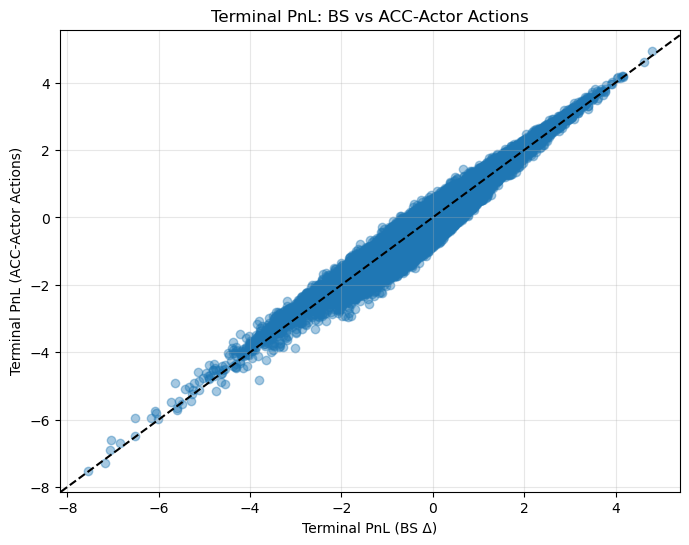

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(
    results_bs["terminal_pnl"],
    acc_results_actions["terminal_pnl"],
    alpha=0.4
)
plt.axline((0, 0), (1, 1), color="black", ls="--")
plt.xlabel("Terminal PnL (BS Δ)")
plt.ylabel("Terminal PnL (ACC-Actor Actions)")
plt.title("Terminal PnL: BS vs ACC-Actor Actions")
plt.grid(alpha=0.3)
plt.show()


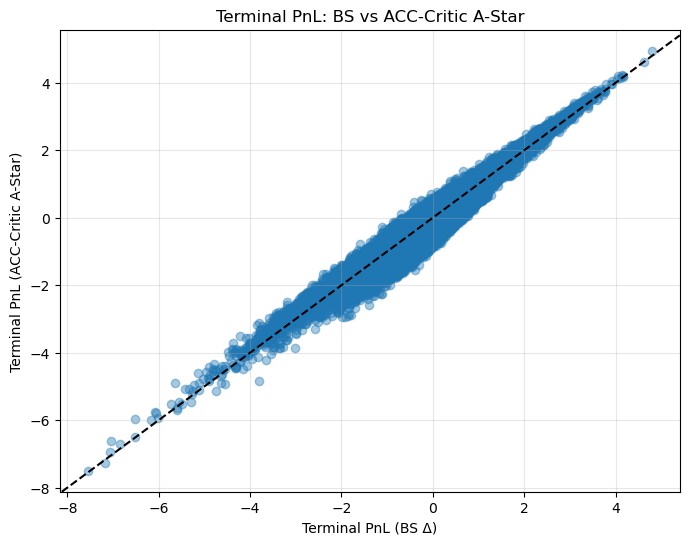

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(
    results_bs["terminal_pnl"],
    acc_results_astar["terminal_pnl"],
    alpha=0.4
)
plt.axline((0, 0), (1, 1), color="black", ls="--")
plt.xlabel("Terminal PnL (BS Δ)")
plt.ylabel("Terminal PnL (ACC-Critic A-Star)")
plt.title("Terminal PnL: BS vs ACC-Critic A-Star")
plt.grid(alpha=0.3)
plt.show()

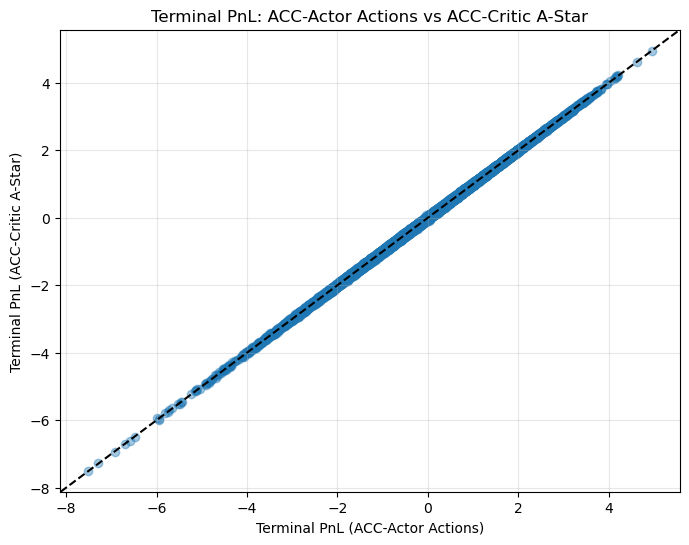

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(
    acc_results_actions["terminal_pnl"],
    acc_results_astar["terminal_pnl"],
    alpha=0.4
)
plt.axline((0, 0), (1, 1), color="black", ls="--")
plt.xlabel("Terminal PnL (ACC-Actor Actions)")
plt.ylabel("Terminal PnL (ACC-Critic A-Star)")
plt.title("Terminal PnL: ACC-Actor Actions vs ACC-Critic A-Star")
plt.grid(alpha=0.3)
plt.show()

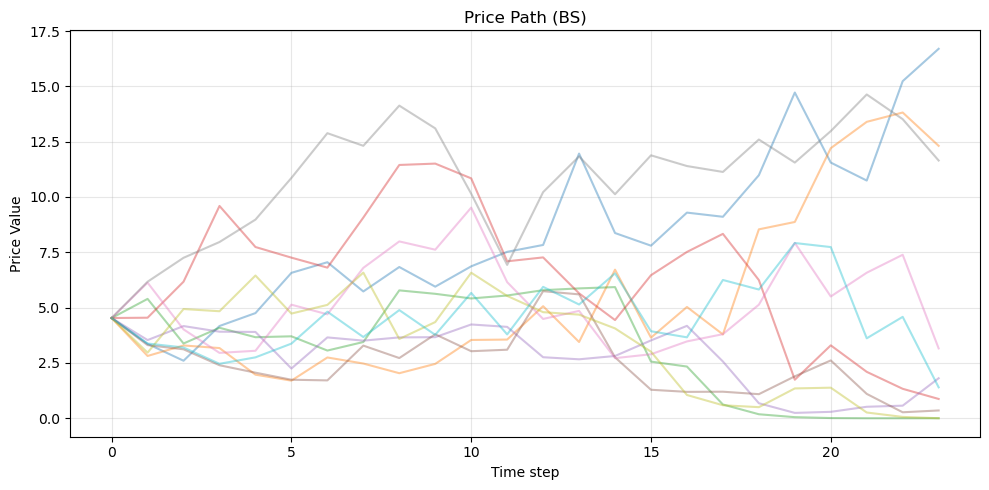

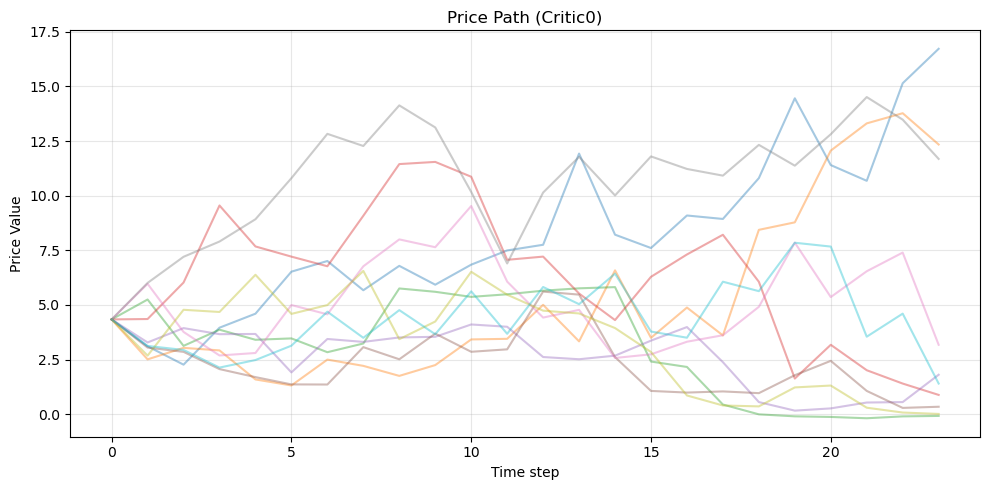

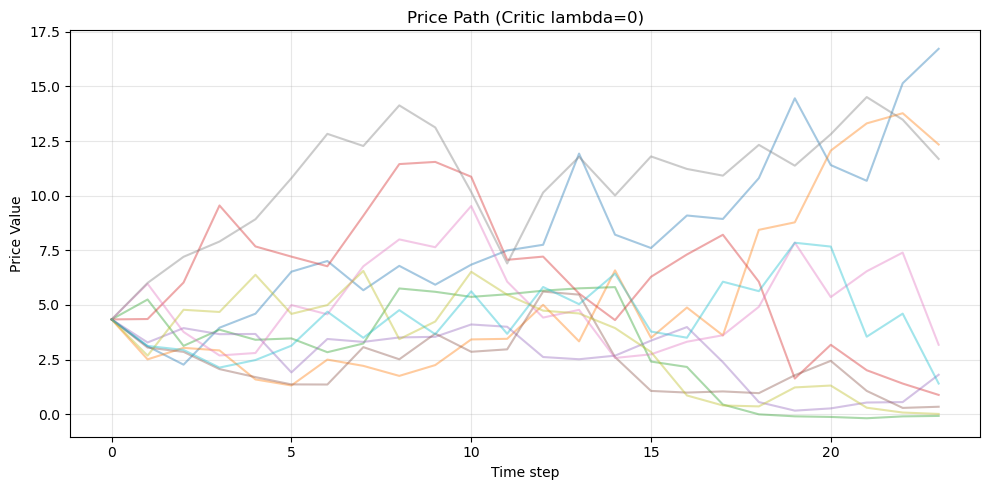

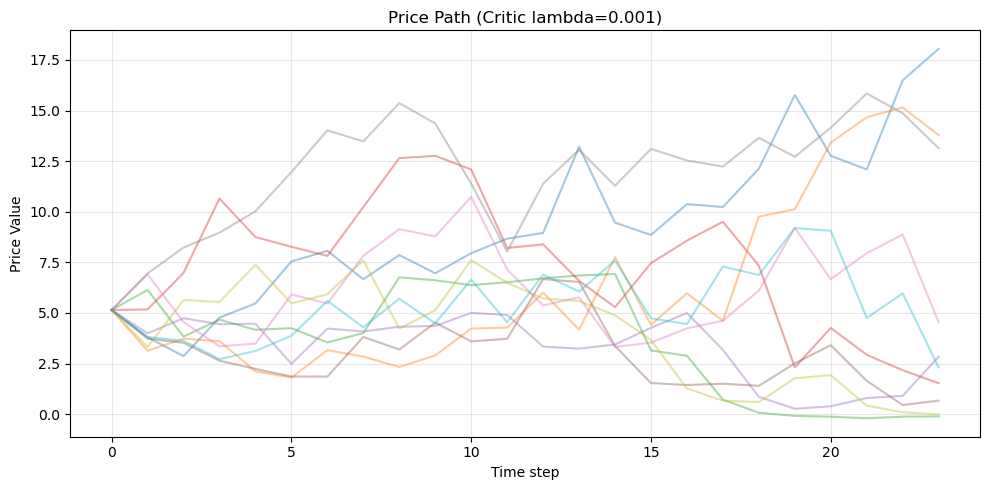

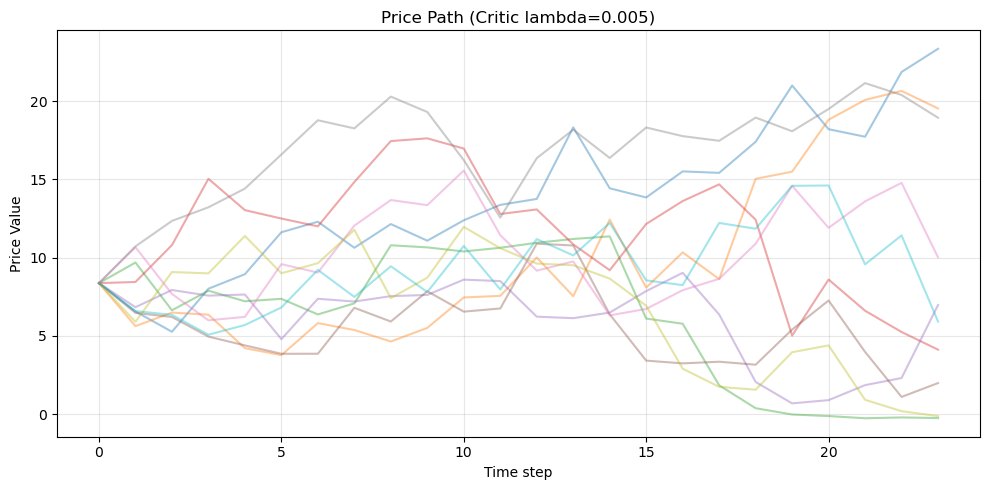

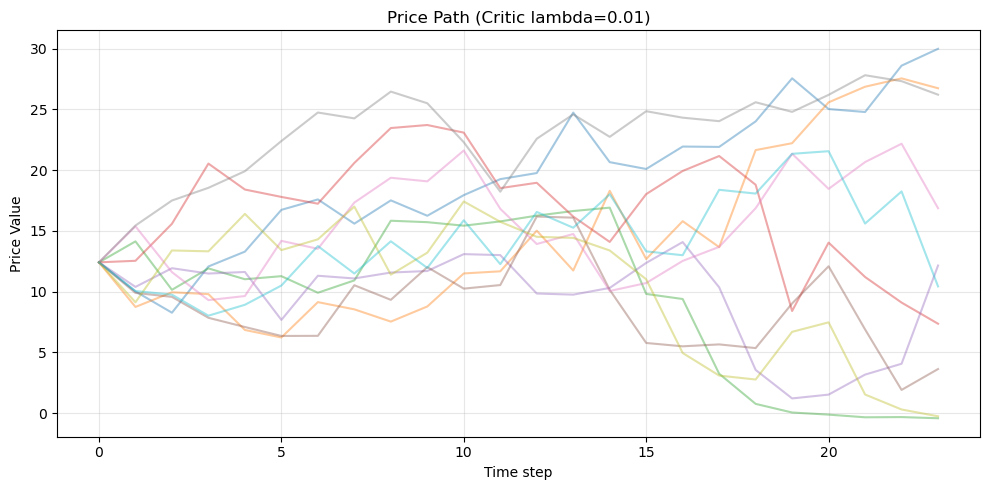

In [46]:

Q_critic0_np = Q_critic0.cpu().detach().numpy()

Q_critic_np = Q_critic.cpu().detach().numpy()
#
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid[:-1], price_mat[i], alpha=0.4)
plt.title("Price Path (BS)")
plt.xlabel("Time step")
plt.ylabel("Price Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t_grid[:-1], Q_critic0_np[i], alpha=0.4)
plt.title("Price Path (Critic0)")
plt.xlabel("Time step")
plt.ylabel("Price Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
n = 0
for l in all_critic_risk_lambda:
    plt.figure(figsize=(10, 5))
    for i in plot_indices:
        plt.plot(t_grid[:-1], Q_critic_np[n, i], alpha=0.4)
    plt.title(f"Price Path (Critic lambda={l})")
    plt.xlabel("Time step")
    plt.ylabel("Price Value")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    n += 1